In [360]:

# Standard Library (Python)
import re
import json
import time
import string
import warnings
from typing import Any

warnings.filterwarnings('ignore')

import nltk
import simplemma
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline as SklearnPipeline


from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, accuracy_score,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SklearnPipeline

nltk.download('stopwords', quiet=True)

# Data Manipulation
import pandas as pd
import numpy as np

from scipy.sparse import vstack

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP / Text Processing
import emoji

# Scikit-learn (ML)
from sklearn.model_selection import train_test_split
from sklearn.base import clone

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    classification_report
)

# Model Persistence
import joblib

In [361]:
base_path = "/home/oafidi/Documents/ai/NLP/data/processed/"
files = [
    base_path + "reviews_labeled_data_arabizi.json",
    base_path + "reviews_labeled_data_darija.json",
    base_path + "reviews_labeled_data_french.json",
    base_path + "reviews_labeled_data_msa.json",
    base_path + "reviews_labeled_data_english.json",
]

df = pd.DataFrame()
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    df = pd.concat([df, pd.DataFrame(data)], ignore_index=True)
df = df.iloc[np.random.permutation(len(df))].reset_index(drop=True)

In [362]:
df.head()

,user_id,place_id,text,rating,lang,sentiment
0,Said Nahid,armen,سلام,5.0,darija,neutral
1,unknown,unknown,دائمًا أشرب من قهوتهم اللذيذة، ولكن هذا الفرع ...,0.0,msa,negative
2,unknown,unknown,لا بأس به، طلبت منه لاتي وكان عادياً؛ المشروبا...,3.0,msa,neutral
3,Majda Rahmani,in_diga_cafe_restaurant_pizzeria,"Bon coin, tranquille et contient un espace non...",4.0,french,positive
4,Abdrahim Touti,gymgold57,Top salle soprt,5.0,english,positive


In [363]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 4328
Total columns: 6


In [364]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4328 entries, 0 to 4327
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    4328 non-null   str    
 1   place_id   4328 non-null   str    
 2   text       4328 non-null   str    
 3   rating     4327 non-null   float64
 4   lang       4328 non-null   str    
 5   sentiment  4328 non-null   str    
dtypes: float64(1), str(5)
memory usage: 1.0 MB


In [365]:

# Count duplicates
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} duplicate rows found.")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected.")

Before: 4328
401 duplicate rows found.
After: 3927


In [366]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

rating    1
dtype: int64


In [367]:
df["rating"] = df["rating"].fillna(3).astype(int)

In [368]:
print("Sentiments: ", list(df["sentiment"].unique()))
print("Languages: ", list(df["lang"].unique()))

Sentiments:  ['neutral', 'negative', 'positive']
Languages:  ['darija', 'msa', 'french', 'english', 'arabizi']


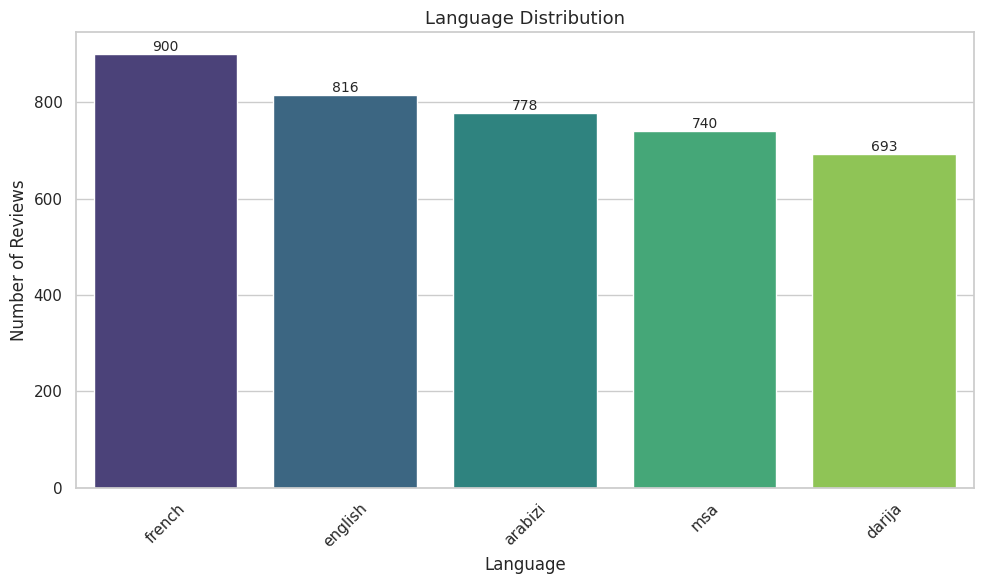

In [369]:

lang_counts = df['lang'].value_counts().reset_index()
lang_counts.columns = ['lang', 'count']

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=lang_counts,
    x='lang',
    y='count',
    hue='lang',
    palette='viridis',
    legend=False
)

plt.title('Language Distribution', fontsize=13)
plt.xlabel('Language')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

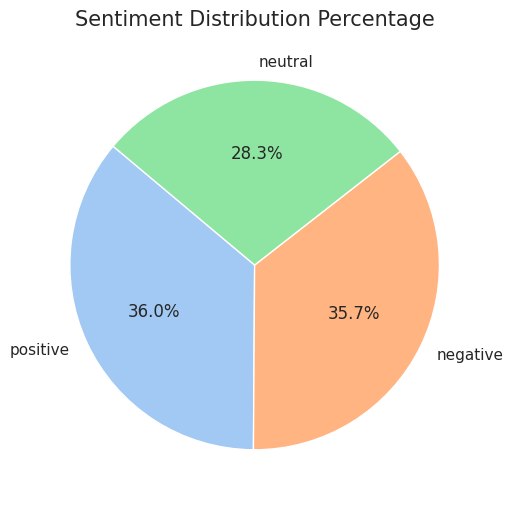

In [370]:
sentiment_counts = df['sentiment'].value_counts()

sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(sentiment_counts)]

plt.figure(figsize=(8, 6))
plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%', # Shows the percentage on the slice
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white'} # Adds a clean border
)

plt.title('Sentiment Distribution Percentage', fontsize=15)
plt.show()

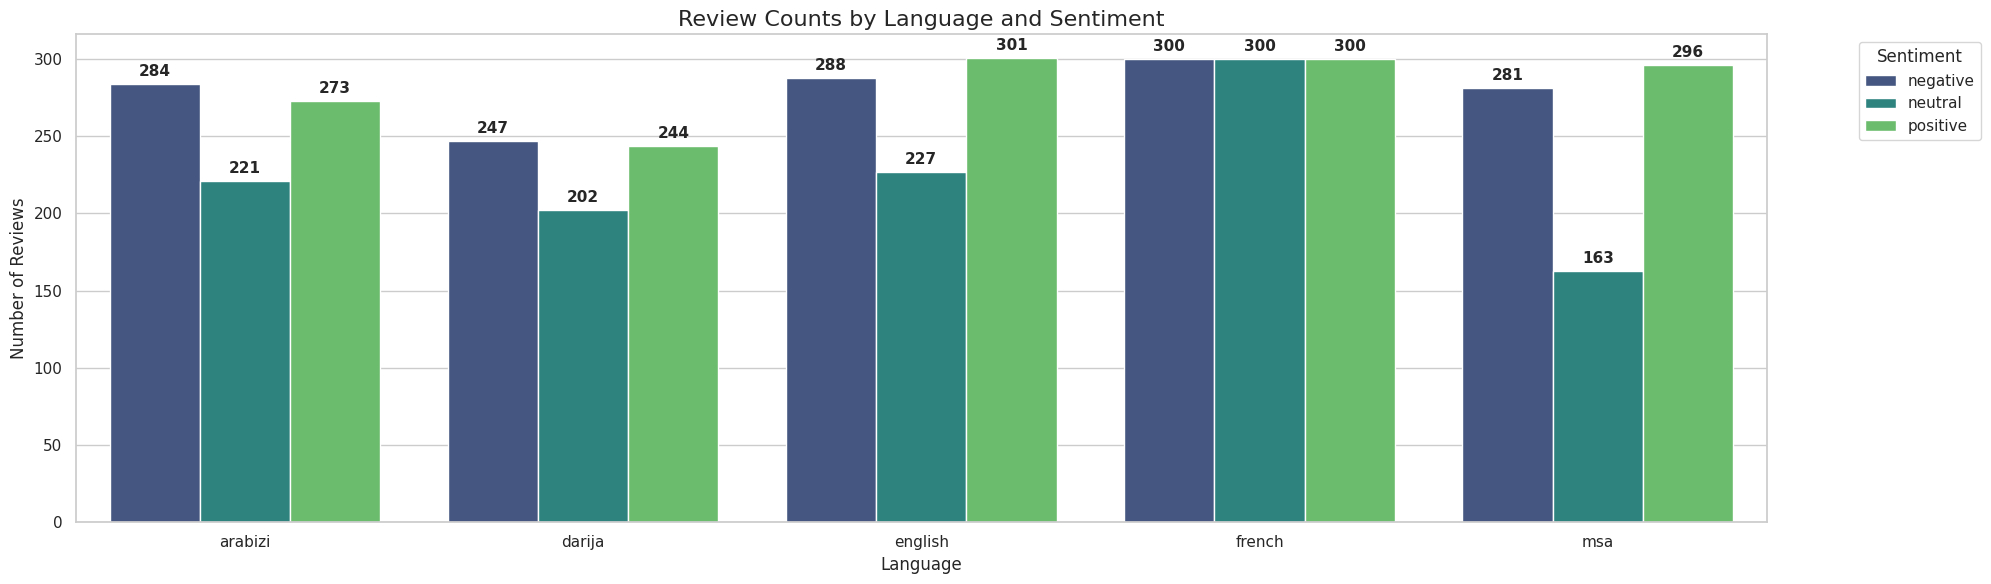

In [371]:
df_counts = df.groupby(['lang', 'sentiment']).size().reset_index(name='review_count')

plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_counts, 
    x='lang', 
    y='review_count', 
    hue='sentiment', 
    palette='viridis'
)

for p in ax.patches:
    if p.get_height() > 0: # Only label bars that have data
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('Review Counts by Language and Sentiment', fontsize=16)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [372]:
def text_preprocessing(text: str) -> str:
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove punctuation
    text = text.translate(
        str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    )
    
    # 3. Replace emojis with their descriptions
    text = emoji.demojize(text, delimiters=(" ", " "))

    tokens = text.split()

    cleaned_tokens = []
    for token in tokens:
        # 4. Remove non-alphanumeric characters (except for Arabic letters)
        token = re.sub(r'[^a-z\u00C0-\u017E\u0600-\u06FF0-9]', '', token)

        if not token:
            continue

        # 5. Keep only tokens that contain at least one letter (to remove standalone numbers)
        has_letter = re.search(r'[a-z\u00C0-\u017E\u0600-\u06FF]', token)
        if has_letter:
            cleaned_tokens.append(token)

        text = ' '.join(cleaned_tokens)

    # 6. Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. Collapse spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text
    

In [373]:
df['text'] = df['text'].apply(text_preprocessing)

In [374]:
def split_data(
    df: pd.DataFrame,
    text_col: str,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    stratify: str | None = "auto",
    verbose: bool = True,
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:

    strat = df[target_col] if stratify == "auto" else stratify
 
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col],
        df[target_col],
        test_size=test_size,
        random_state=random_state,
        stratify=strat,
    )
 
    if verbose:
        print(f"Train : {len(X_train):,} samples")
        print(f"Test  : {len(X_test):,} samples")
 
    return X_train, X_test, y_train, y_test

In [375]:
X_train, X_test, y_train, y_test = split_data(
    df,
    text_col='text',
    target_col='sentiment',
    verbose=True
    )

Train : 3,141 samples
Test  : 786 samples


In [376]:
VectorizedData = dict[str, dict[str, Any]]

vectorizers = {
    'BoW'    : CountVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=30000),
    'TFIDF-word' : TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=30000, sublinear_tf=True),
    'TF-IDF-char' : TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=30000, sublinear_tf=True),
}

def precompute_vectorizations(
    vectorizers: dict[str, Any],
    X_train: pd.Series,
    X_test: pd.Series,
    verbose: bool = True,
) -> VectorizedData:

    vectorized_data: VectorizedData = {}
 
    for vec_name, vectorizer in vectorizers.items():
        if verbose:
            print(f"Fitting {vec_name}...")
 
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec  = vectorizer.transform(X_test)
 
        vectorized_data[vec_name] = {
            "X_train"   : X_train_vec,
            "X_test"    : X_test_vec,
            "vectorizer": vectorizer,
        }
 
        if verbose:
            print(f"  → shape : {X_train_vec.shape}")
 
    return vectorized_data



In [377]:
vectorized_data = precompute_vectorizations(vectorizers, X_train, X_test)

Fitting BoW...
  → shape : (3141, 30000)
Fitting TFIDF-word...
  → shape : (3141, 30000)
Fitting TF-IDF-char...
  → shape : (3141, 30000)


In [378]:
TrainedModels  = dict[tuple[str, str], Any] 

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                 : LinearSVC(max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

def evaluate_models(
    vectorized_data: VectorizedData,
    classifiers: dict[str, Any],
    y_train: pd.Series,
    y_test: pd.Series,
    verbose: bool = True,
) -> tuple[pd.DataFrame, TrainedModels]:
    records: list[dict] = []
    trained_models: TrainedModels = {}

    for vec_name, data in vectorized_data.items():
        X_tr = data["X_train"]
        X_te = data["X_test"]

        for clf_name, clf in classifiers.items():
            model = clone(clf)
            start = time.time()
            model.fit(X_tr, y_train)
            train_time = time.time() - start

            # Test metrics
            y_pred      = model.predict(X_te)
            f1          = f1_score(y_test, y_pred, average="weighted")
            acc         = accuracy_score(y_test, y_pred)

            # Train metrics
            y_pred_train = model.predict(X_tr)
            f1_train     = f1_score(y_train, y_pred_train, average="weighted")
            acc_train    = accuracy_score(y_train, y_pred_train)

            records.append({
                "Vectorizer"  : vec_name,
                "Model"       : clf_name,
                "Acc Train"   : round(float(acc_train), 4),
                "Acc Test"    : round(float(acc), 4),
                "F1 Train"    : round(float(f1_train), 4),
                "F1 Test"     : round(float(f1), 4),
                "Train Time"  : round(float(train_time), 3),
            })
            trained_models[(vec_name, clf_name)] = model

            if verbose:
                print(
                    f"[{vec_name:<7}] {clf_name:<22} "
                    f"| Train F1={f1_train:.4f} Acc={acc_train:.4f}"
                    f"| Test  F1={f1:.4f} Acc={acc:.4f}"
                    f"| {train_time:.2f}s"
                )

    results_df = (
        pd.DataFrame(records)
        .sort_values("F1 Test", ascending=False)
        .reset_index(drop=True)
    )
    return results_df, trained_models

In [379]:
results_df, trained_models = evaluate_models(vectorized_data, classifiers, y_train, y_test)

[BoW    ] Logistic Regression    | Train F1=0.9971 Acc=0.9971| Test  F1=0.7358 Acc=0.7354| 8.56s
[BoW    ] SVM                    | Train F1=0.9975 Acc=0.9975| Test  F1=0.7079 Acc=0.7074| 2.38s
[BoW    ] Random Forest          | Train F1=0.9990 Acc=0.9990| Test  F1=0.7178 Acc=0.7201| 0.47s
[TFIDF-word] Logistic Regression    | Train F1=0.9664 Acc=0.9666| Test  F1=0.7194 Acc=0.7328| 1.14s
[TFIDF-word] SVM                    | Train F1=0.9949 Acc=0.9949| Test  F1=0.7468 Acc=0.7506| 0.04s
[TFIDF-word] Random Forest          | Train F1=0.9952 Acc=0.9952| Test  F1=0.7043 Acc=0.7036| 0.52s
[TF-IDF-char] Logistic Regression    | Train F1=0.9203 Acc=0.9207| Test  F1=0.7452 Acc=0.7506| 1.42s
[TF-IDF-char] SVM                    | Train F1=0.9876 Acc=0.9876| Test  F1=0.7545 Acc=0.7570| 0.14s
[TF-IDF-char] Random Forest          | Train F1=0.9990 Acc=0.9990| Test  F1=0.7240 Acc=0.7277| 0.43s


In [380]:
print("\nEvaluation Results:")
print(results_df.to_string(index=False))


Evaluation Results:
 Vectorizer               Model  Acc Train  Acc Test  F1 Train  F1 Test  Train Time
TF-IDF-char                 SVM     0.9876    0.7570    0.9876   0.7545       0.143
 TFIDF-word                 SVM     0.9949    0.7506    0.9949   0.7468       0.040
TF-IDF-char Logistic Regression     0.9207    0.7506    0.9203   0.7452       1.418
        BoW Logistic Regression     0.9971    0.7354    0.9971   0.7358       8.563
TF-IDF-char       Random Forest     0.9990    0.7277    0.9990   0.7240       0.430
 TFIDF-word Logistic Regression     0.9666    0.7328    0.9664   0.7194       1.145
        BoW       Random Forest     0.9990    0.7201    0.9990   0.7178       0.466
        BoW                 SVM     0.9975    0.7074    0.9975   0.7079       2.380
 TFIDF-word       Random Forest     0.9952    0.7036    0.9952   0.7043       0.523


In [381]:
def plot_top_confusion_matrices(
    results_df: pd.DataFrame,
    trained_models: TrainedModels,
    vectorized_data: VectorizedData,
    y_test: pd.Series,
    top_n: int = 2,
) -> None:

    top_models = results_df.head(top_n)
 
    fig, axes = plt.subplots(1, top_n, figsize=(9 * top_n, 7))
    if top_n == 1:
        axes = [axes]
 
    for rank, (ax, (_, row)) in enumerate(zip(axes, top_models.iterrows()), start=1):
        vec_name = row["Vectorizer"]
        clf_name = row["Model"]
 
        key = (vec_name, clf_name)
        if key not in trained_models:
            raise KeyError(
                f"Model '{clf_name}' + Vectorizer '{vec_name}' "
                f"Not found in trained_models."
            )
 
        model  = trained_models[key]
        X_test = vectorized_data[vec_name]["X_test"]
        y_pred = model.predict(X_test)
 
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            cmap    ="Blues",
            ax      = ax,
            colorbar= True,
        )
        ax.set_title(
            f"#{rank} — {vec_name} + {clf_name}\n"
            f"F1={row['F1 Test']:.4f} | Acc={row['Acc Test']:.4f}",
            fontsize=13,
        )
 
    plt.suptitle(
        f" Confusion Matrix — Top {top_n} Models",
        fontsize=15, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()


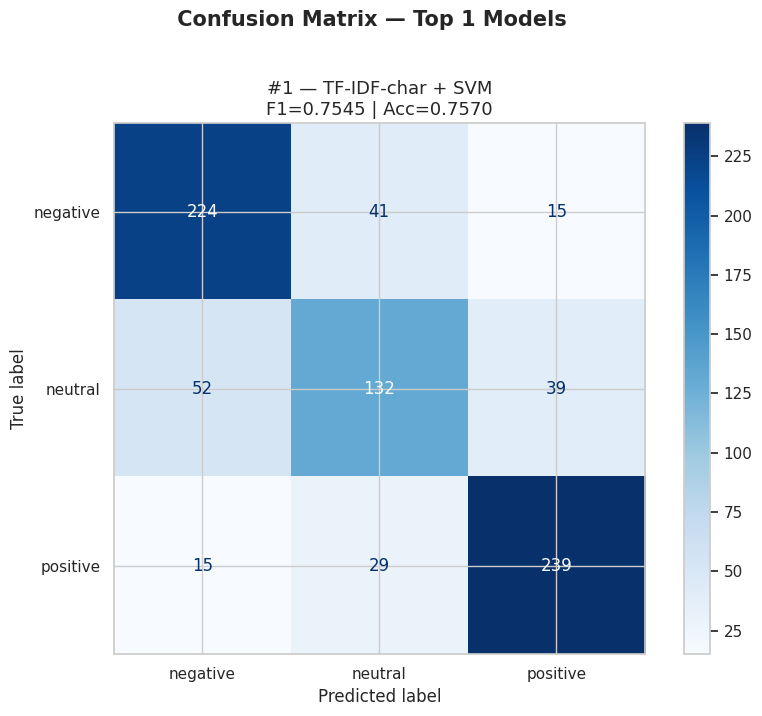

In [382]:
plot_top_confusion_matrices(results_df, trained_models, vectorized_data, y_test, top_n=1)

In [383]:
def plot_top_confusion_matrices_by_lang(
    results_df: pd.DataFrame,
    trained_models: dict,
    vectorized_data: dict,
    y_test: pd.Series,
    df_test_original: pd.DataFrame,
    top_n: int = 1,
) -> None:

    languages = df_test_original['lang'].unique()
    top_n = min(top_n, len(results_df))
    top_models = results_df.head(top_n)

    n_langs = len(languages)

    fig, axes = plt.subplots(
        top_n, n_langs,
        figsize=(6 * n_langs, 7 * top_n)
    )

    if top_n == 1 and n_langs == 1:
        axes = np.array([[axes]])
    elif top_n == 1:
        axes = np.array([axes])
    elif n_langs == 1:
        axes = np.array([[ax] for ax in axes])

    assert len(df_test_original) == next(
        iter(vectorized_data.values())
    )["X_test"].shape[0], "Désalignement détecté entre df_test_original et X_test"

    for row_idx, (_, row) in enumerate(top_models.iterrows()):
        vec_name, clf_name = row["Vectorizer"], row["Model"]
        key = (vec_name, clf_name)

        for col_idx, lang in enumerate(languages):
            ax = axes[row_idx, col_idx]

            if key not in trained_models or vec_name not in vectorized_data:
                ax.set_visible(False)
                continue

            X_test_all = vectorized_data[vec_name]["X_test"]
            lang_mask = (df_test_original['lang'] == lang)

            X_test_lang = X_test_all[lang_mask.values]
            y_test_lang = y_test[lang_mask]
            y_pred_lang = trained_models[key].predict(X_test_lang)

            lang_f1 = f1_score(y_test_lang, y_pred_lang, average='weighted')

            ConfusionMatrixDisplay.from_predictions(
                y_test_lang, y_pred_lang,
                cmap="Blues", ax=ax, colorbar=False
            )
            
            ax.set_title(
                f"Lang: {lang} | F1: {lang_f1:.4f} | Rank #{row_idx + 1}\n{vec_name} + {clf_name}",
                fontsize=10
            )

    plt.suptitle(
        f"Confusion Matrices per Language — Top {top_n} Models",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

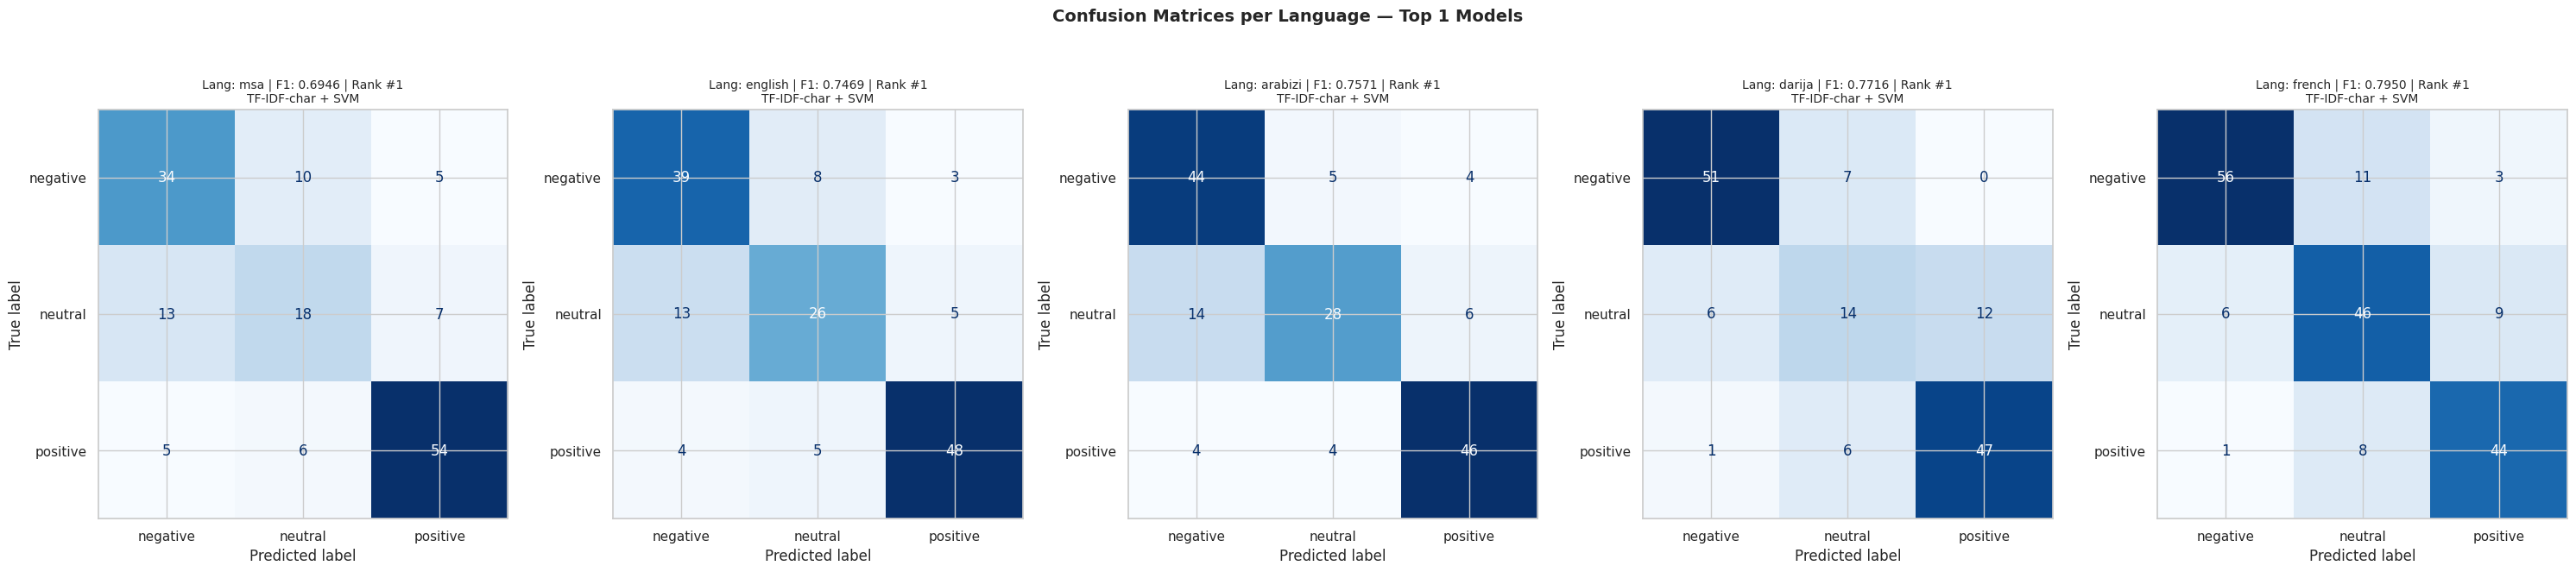

In [384]:
plot_top_confusion_matrices_by_lang(
    results_df,
    trained_models,
    vectorized_data,
    y_test,
    df_test_original=df.iloc[y_test.index],
    top_n=1
)

In [385]:
test = "9ehwa kharya fiha gha lhedya"

best_model_key = (results_df.loc[0, "Vectorizer"], results_df.loc[0, "Model"])
best_model = trained_models[best_model_key]
best_vectorizer = vectorized_data[results_df.loc[0, "Vectorizer"]]["vectorizer"]
test_vec = best_vectorizer.transform([test])
pred = best_model.predict(test_vec)
print(f"Test: '{test}' → Predicted Sentiment: '{pred[0]}'")

Test: '9ehwa kharya fiha gha lhedya' → Predicted Sentiment: 'negative'


In [386]:
base_path = "/home/oafidi/Documents/ai/NLP/data/processed/"
files = [
    base_path + "reviews_labeled_data_arabizi_v3.json",
    base_path + "reviews_labeled_data_darija_v3.json",
    base_path + "reviews_labeled_data_french_v3.json",
    base_path + "reviews_labeled_data_msa_v3.json",
    base_path + "reviews_labeled_data_english_v3.json",
]

df = pd.DataFrame()
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    df = pd.concat([df, pd.DataFrame(data)], ignore_index=True)
df = df.iloc[np.random.permutation(len(df))].reset_index(drop=True)

In [387]:

# Count duplicates
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} duplicate rows found.")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected.")

Before: 8492
1233 duplicate rows found.
After: 7259


In [388]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

rating    1
dtype: int64


In [389]:
df["rating"] = df["rating"].fillna(3).astype(int)

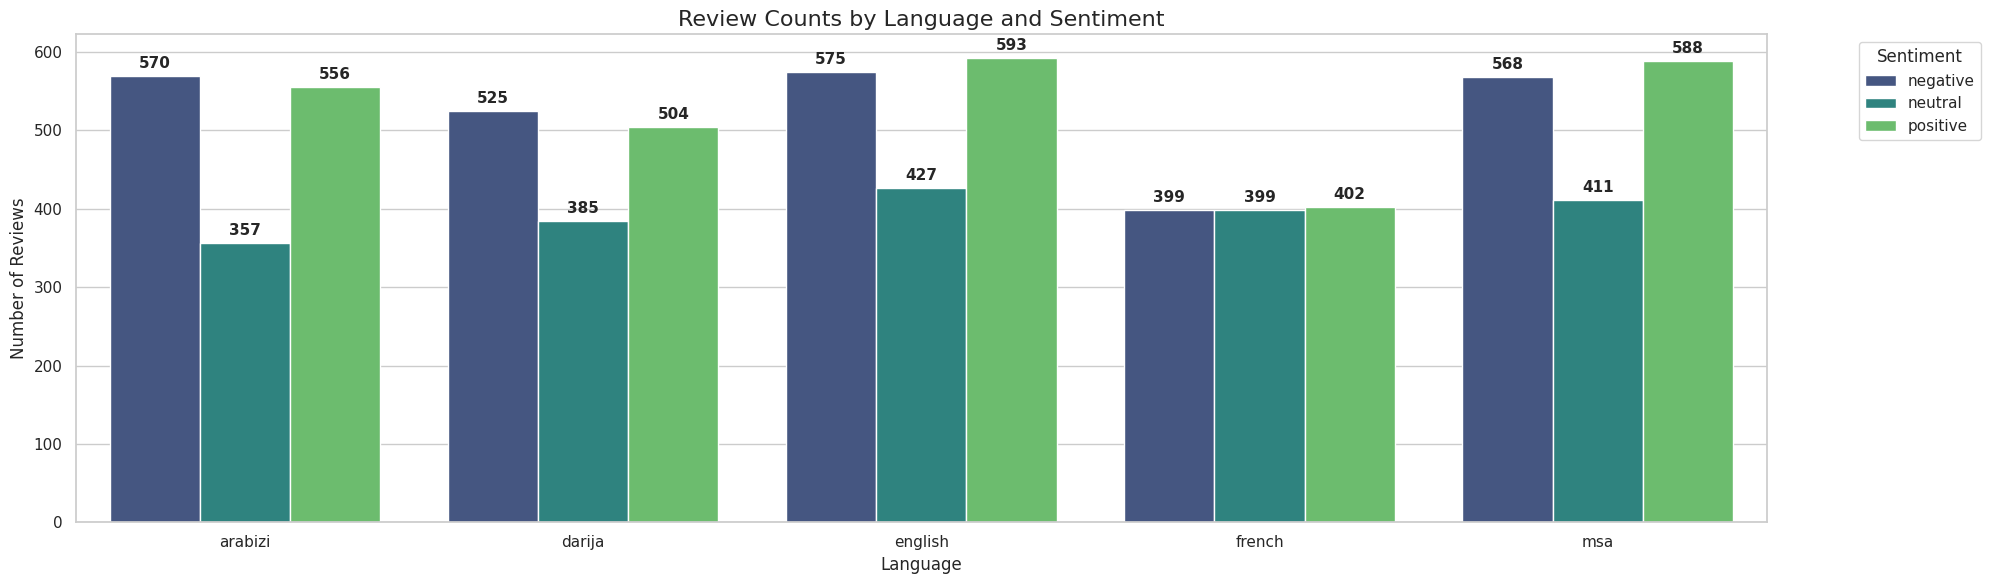

In [390]:
df_counts = df.groupby(['lang', 'sentiment']).size().reset_index(name='review_count')

plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_counts, 
    x='lang', 
    y='review_count', 
    hue='sentiment', 
    palette='viridis'
)

for p in ax.patches:
    if p.get_height() > 0: # Only label bars that have data
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('Review Counts by Language and Sentiment', fontsize=16)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [391]:
df['text'] = df['text'].apply(text_preprocessing)

In [392]:
X_train, X_test, y_train, y_test = split_data(
    df,
    text_col='text',
    target_col='sentiment',
    verbose=True
    )

Train : 5,807 samples
Test  : 1,452 samples


In [393]:
vectorized_data = precompute_vectorizations(vectorizers, X_train, X_test)

Fitting BoW...
  → shape : (5807, 30000)
Fitting TFIDF-word...
  → shape : (5807, 30000)
Fitting TF-IDF-char...
  → shape : (5807, 30000)


In [394]:
results_df, trained_models = evaluate_models(vectorized_data, classifiers, y_train, y_test)

[BoW    ] Logistic Regression    | Train F1=0.9955 Acc=0.9955| Test  F1=0.7942 Acc=0.7941| 13.35s
[BoW    ] SVM                    | Train F1=0.9962 Acc=0.9962| Test  F1=0.7766 Acc=0.7775| 3.86s
[BoW    ] Random Forest          | Train F1=0.9983 Acc=0.9983| Test  F1=0.7624 Acc=0.7665| 1.08s
[TFIDF-word] Logistic Regression    | Train F1=0.9601 Acc=0.9602| Test  F1=0.7863 Acc=0.7920| 1.04s
[TFIDF-word] SVM                    | Train F1=0.9926 Acc=0.9926| Test  F1=0.8123 Acc=0.8147| 0.06s
[TFIDF-word] Random Forest          | Train F1=0.9948 Acc=0.9948| Test  F1=0.7569 Acc=0.7569| 1.11s
[TF-IDF-char] Logistic Regression    | Train F1=0.9215 Acc=0.9220| Test  F1=0.7936 Acc=0.7961| 1.76s
[TF-IDF-char] SVM                    | Train F1=0.9838 Acc=0.9838| Test  F1=0.8207 Acc=0.8223| 0.29s
[TF-IDF-char] Random Forest          | Train F1=0.9983 Acc=0.9983| Test  F1=0.7498 Acc=0.7534| 1.00s


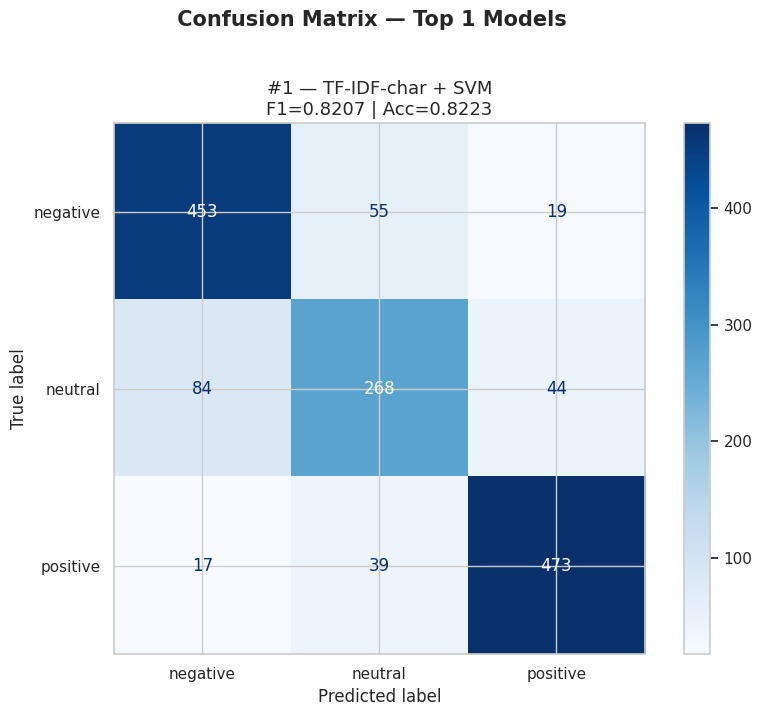

In [395]:
plot_top_confusion_matrices(results_df, trained_models, vectorized_data, y_test, top_n=1)

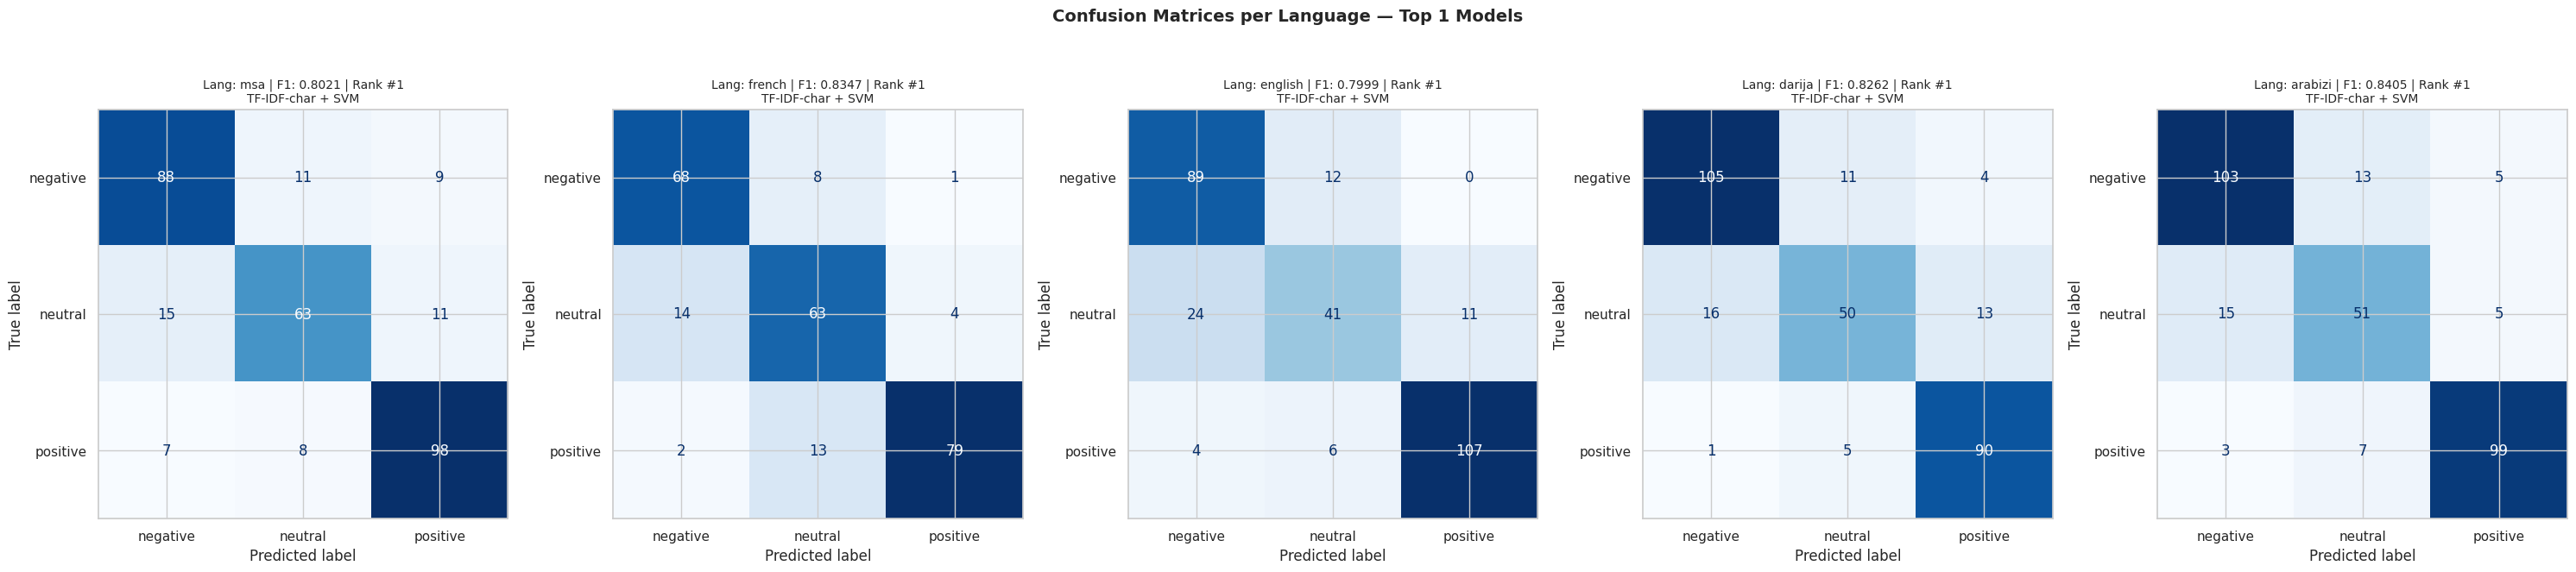

In [396]:
plot_top_confusion_matrices_by_lang(
    results_df,
    trained_models,
    vectorized_data,
    y_test,
    df_test_original=df.iloc[y_test.index],
    top_n=1
)

In [353]:
import os

def save_best_model(
    results_df: pd.DataFrame,
    trained_models: TrainedModels,
    vectorized_data: VectorizedData,
    save_path: str,
) -> dict[str, Any]:

    best_row = results_df.iloc[0]
    best_vec = best_row["Vectorizer"]
    best_clf = best_row["Model"]
 
    key = (best_vec, best_clf)
    if key not in trained_models:
        raise KeyError(
            f"Model '{best_clf}' + Vectorizer '{best_vec}' "
            f"Not found in trained_models."
        )
 
    bundle = {
        "model"     : trained_models[key],
        "vectorizer": vectorized_data[best_vec]["vectorizer"],
        "vec_name"  : best_vec,
        "clf_name"  : best_clf,
        "f1"        : best_row["F1 Test"],
        "accuracy"  : best_row["Acc Test"],
    }
 
    os.makedirs(save_path, exist_ok=True)
    joblib.dump(bundle["model"],       f"{save_path}/model.pkl")
    joblib.dump(bundle["vectorizer"],  f"{save_path}/vectorizer.pkl")
 
    meta = {k: v for k, v in bundle.items() if k not in ("model", "vectorizer")}

    with open(f"{save_path}/meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
 
    return bundle


In [354]:
save_best_model(results_df, trained_models, vectorized_data, save_path="../models/best_model_sentiment_analysis")

{'model': LinearSVC(max_iter=2000, random_state=42),
 'vectorizer': TfidfVectorizer(analyzer='char_wb', max_features=30000, ngram_range=(2, 5),
                 sublinear_tf=True),
 'vec_name': 'TF-IDF-char',
 'clf_name': 'SVM',
 'f1': 0.8356,
 'accuracy': 0.8375}

In [355]:
def mixup_augment_vectorized(
    vectorized_data: VectorizedData,
    y_train: pd.Series,
    df_train: pd.DataFrame,
    n_samples: int = 1000,
    random_state: int = 42,
    verbose: bool = True,
) -> tuple[VectorizedData, pd.Series]:

    rng   = np.random.default_rng(random_state)
    y_arr = np.array(y_train)
    langs = np.array(df_train["lang"])
    unique_langs = np.unique(langs)

    strategies = [
        ("neutral", "neutral", "neutral", (0.1,  0.4)),
        ("positive", "positive", "positive", (0.1,  0.4)),
        ("negative", "negative", "negative", (0.1,  0.4)),
    ]

    idx = {
        (label, lang): np.where((y_arr == label) & (langs == lang))[0]
        for label in np.unique(y_arr)
        for lang  in unique_langs
    }

    # 1. Construire les combinaisons valides d'abord
    valid_combos = [
        (l1, l2, label_out, lmin, lmax, lang)
        for l1, l2, label_out, (lmin, lmax) in strategies
        for lang in unique_langs
        if (l1, lang) in idx and (l2, lang) in idx
        and len(idx[(l1, lang)]) >= 2
        and len(idx[(l2, lang)]) >= 2
    ]

    if not valid_combos:
        raise ValueError("Aucune combinaison valide trouvée.")

    # 2. per_strat basé sur combos valides → n_samples respecté
    per_strat = n_samples // len(valid_combos)
    remainder = n_samples  - per_strat * len(valid_combos)

    plan = []
    for k, (l1, l2, label_out, lmin, lmax, lang) in enumerate(valid_combos):
        # Distribuer le remainder sur les premiers combos
        n = per_strat + (1 if k < remainder else 0)

        i_idx = rng.choice(idx[(l1, lang)], size=n)
        j_idx = rng.choice(idx[(l2, lang)], size=n)
        lams  = rng.uniform(lmin, lmax,     size=n)

        for i, j, lam in zip(i_idx, j_idx, lams):
            plan.append((i, j, lam, label_out))

    if verbose:
        total = len(plan)
        dist  = pd.Series([label for *_, label in plan]).value_counts()
        print(f"Mixup plan : {total} samples générés")
        print(dist.to_string())

    # 3. Appliquer sur chaque vectorizer avec seuil adaptatif
    augmented_data = {}
    for vec_name, data in vectorized_data.items():
        X_tr = data["X_train"]

        # Seuil adaptatif selon le vectorizer
        threshold = 0.01 if "TF-IDF" in vec_name else 0.5

        new_rows = []
        for i, j, lam, _ in plan:
            mixed = lam * X_tr[i] + (1 - lam) * X_tr[j]
            mixed[mixed < threshold] = 0
            mixed.eliminate_zeros()
            new_rows.append(mixed)

        augmented_data[vec_name] = {
            **data,
            "X_train": vstack([X_tr] + new_rows),
        }

        if verbose:
            orig_shape = X_tr.shape
            new_shape  = augmented_data[vec_name]["X_train"].shape
            print(f"  [{vec_name}] {orig_shape[0]} → {new_shape[0]} samples")

    y_aug = pd.Series(
        np.concatenate([y_arr, [label for *_, label in plan]]),
        name=y_train.name
    )

    return augmented_data, y_aug

In [356]:
vectorized_data = precompute_vectorizations(vectorizers, X_train, X_test)

Fitting BoW...
  → shape : (5807, 30000)
Fitting TFIDF-word...
  → shape : (5807, 30000)
Fitting TF-IDF-char...
  → shape : (5807, 30000)


In [357]:
df_train = df.loc[X_train.index]

vectorized_data_aug, y_train_aug = mixup_augment_vectorized(
    vectorized_data, y_train,
    df_train=df_train,
    n_samples=750
)

Mixup plan : 750 samples générés
neutral     250
positive    250
negative    250
  [BoW] 5807 → 6557 samples
  [TFIDF-word] 5807 → 6557 samples
  [TF-IDF-char] 5807 → 6557 samples


In [358]:
results_aug, trained_models_aug = evaluate_models(
    vectorized_data_aug, classifiers, y_train_aug, y_test
)

[BoW    ] Logistic Regression    | Train F1=0.9948 Acc=0.9948| Test  F1=0.8050 Acc=0.8051| 12.31s
[BoW    ] SVM                    | Train F1=0.9960 Acc=0.9960| Test  F1=0.7912 Acc=0.7920| 3.90s
[BoW    ] Random Forest          | Train F1=0.9986 Acc=0.9986| Test  F1=0.7606 Acc=0.7638| 1.10s
[TFIDF-word] Logistic Regression    | Train F1=0.8936 Acc=0.8935| Test  F1=0.7759 Acc=0.7817| 1.24s
[TFIDF-word] SVM                    | Train F1=0.9272 Acc=0.9250| Test  F1=0.8112 Acc=0.8134| 0.06s
[TFIDF-word] Random Forest          | Train F1=0.9284 Acc=0.9274| Test  F1=0.7306 Acc=0.7348| 1.11s
[TF-IDF-char] Logistic Regression    | Train F1=0.9283 Acc=0.9286| Test  F1=0.8047 Acc=0.8065| 1.03s
[TF-IDF-char] SVM                    | Train F1=0.9838 Acc=0.9838| Test  F1=0.8345 Acc=0.8361| 0.33s
[TF-IDF-char] Random Forest          | Train F1=0.9986 Acc=0.9986| Test  F1=0.7743 Acc=0.7769| 1.07s


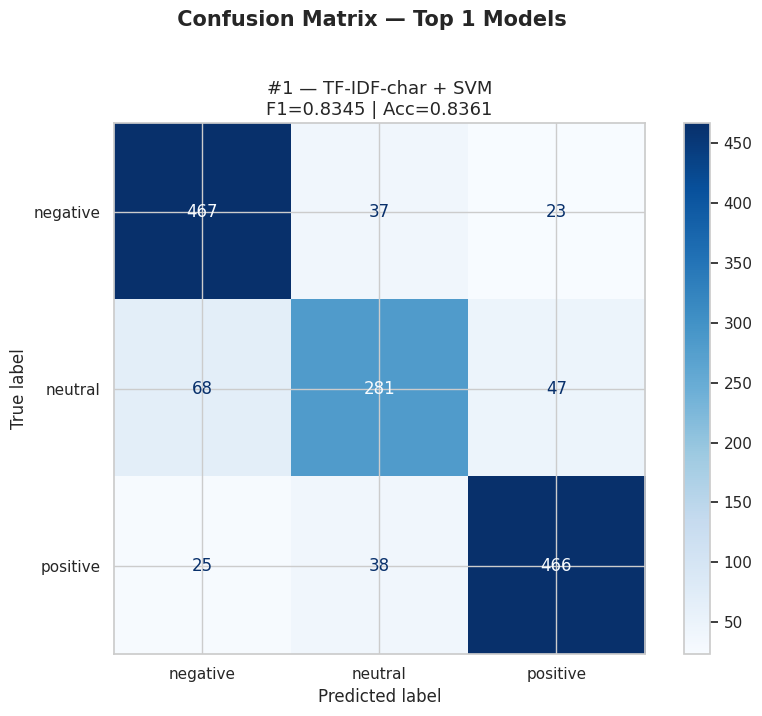

In [359]:
plot_top_confusion_matrices(results_aug, trained_models_aug, vectorized_data_aug, y_test, top_n=1)

In [397]:
base_path = "/home/oafidi/Documents/ai/NLP/data/processed/"
files = [
    base_path + "reviews_labeled_data_french_v3.json",
]

df = pd.DataFrame()
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    df = pd.concat([df, pd.DataFrame(data)], ignore_index=True)
df = df.iloc[np.random.permutation(len(df))].reset_index(drop=True)

In [398]:
df.head()

,user_id,place_id,rating,sentiment,lang,text
0,el_m4hdi flusss,pizzeria_napoli,5,positive,french,Très très bien 👍🏾👍🏾 …
1,maadane youness,palace_andalouse,1,negative,french,"Le grand nombre de fumeurs, que Dieu leur pard..."
2,laazouzi maryem,esthe_marbella__esthetique__beaute,1,negative,english,"Appointment set for 3 PM, but went in at 6:02 ..."
3,Amin Khidri,cafe_du_soir,3,positive,french,"Le nid est un espace normal, pratique et popul..."
4,Délices Salwita,paradise_meal_patisserie,1,negative,english,"There's nothing to say, it's really catastrophic."


In [399]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 1915
Total columns: 6


In [400]:

# Count duplicates
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} duplicate rows found.")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected.")

No duplicate values detected.


In [401]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

Series([], dtype: int64)


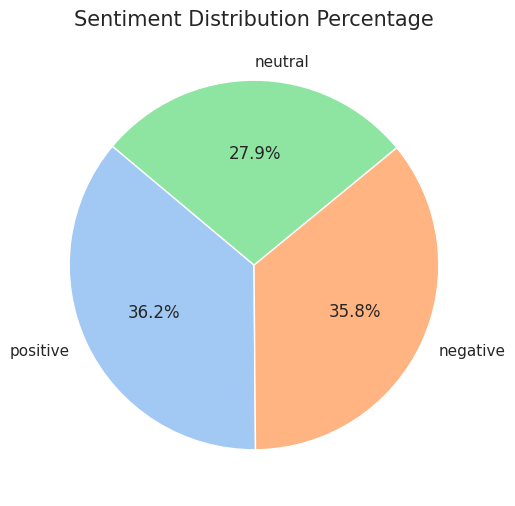

In [402]:
sentiment_counts = df['sentiment'].value_counts()

sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(sentiment_counts)]

plt.figure(figsize=(8, 6))
plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%', # Shows the percentage on the slice
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white'} # Adds a clean border
)

plt.title('Sentiment Distribution Percentage', fontsize=15)
plt.show()

In [403]:
def extract_all_emojis(df, column_name="text"):

    all_emojis = []

    for row in df[column_name].dropna():
        res = emoji.analyze(row)
        for entry in res:
            all_emojis.append(entry.chars)
            
    return set(all_emojis)

In [404]:
extract_all_emojis(df)

{'☕',
 '♥️',
 '⛹️',
 '✌️',
 '✨',
 '❤',
 '❤️',
 '⭐',
 '🌮',
 '🌸',
 '🍁',
 '🍂',
 '🍕',
 '👌',
 '👌🏻',
 '👍',
 '👍🏻',
 '👍🏼',
 '👍🏾',
 '👎',
 '👎🏻',
 '👏',
 '👐',
 '💗',
 '💥',
 '💪🏽',
 '💯',
 '🔥',
 '😁',
 '😃',
 '😅',
 '😆',
 '😈',
 '😊',
 '😋',
 '😍',
 '😑',
 '😔',
 '😕',
 '😘',
 '😜',
 '😡',
 '😬',
 '😰',
 '😳',
 '😻',
 '🙂',
 '🙏🏼',
 '🚬',
 '🤗',
 '🤙',
 '🤢',
 '🤤',
 '🤮',
 '🥇',
 '🥗',
 '🥢',
 '🥰',
 '🧐',
 '🫶',
 '🫶🏻'}

In [405]:
emoji_to_french = {
    # Sentiments Positifs / Joie
    '😁': ' très heureux ', '😃': ' sourit ', '😅': ' soulagé ', '😆': ' rire ',
    '😊': ' satisfait ', '😋': ' miam ', '😍': ' amoureux ', '😘': ' bisou ',
    '😜': ' taquin ', '😻': ' adore ', '🙂': ' content ', '🤗': ' câlin ',
    '🥰': ' adoré ', '🤤': ' envie ', '😆': ' rire ',

    # Sentiments Négatifs / Colère / Malaise
    '😑': ' inexpressif ', '😔': ' triste ', '😕': ' confus ', '😡': ' en colère ',
    '😬': ' grimaçant ', '😰': ' inquiet ', '😳': ' choqué ', '🤢': ' dégoûté ',
    '🤮': ' vomi ', '😈': ' malicieux ',

    # Gestes et Mains
    '✌️': ' victoire ', '👌': ' parfait ', '👌🏻': ' parfait ', '👍': ' super ',
    '👍🏻': ' super ', '👍🏼': ' super ', '👍🏾': ' super ', '👎': ' nul ',
    '👎🏻': ' nul ', '👏': ' bravo ', '👐': ' ouvert ', '💪🏽': ' force ',
    '🙏🏼': ' prière ', '🤙': ' signe appel ', '🫶': ' coeur avec les mains ',
    '🫶🏻': ' coeur avec les mains ',

    # Coeurs et Symboles de Sentiment
    '♥️': ' coeur ', '❤': ' coeur ', '❤️': ' coeur ', '💗': ' coeur battant ',
    '✨': ' étincelles ', '💥': ' explosion ', '💯': ' parfait cent ', '🔥': ' génial ',
    '🥇': ' premier ', '⭐': ' étoile ',

    # Objets / Food / Nature
    '☕': ' café ', '🌮': ' taco ', '🍕': ' pizza ', '🥗': ' salade ',
    '🌸': ' fleur ', '🍁': ' feuille automne ', '🍂': ' feuilles mortes ',
    '🚬': ' cigarette ', '🥢': ' baguettes ', '🧐': ' analyse ', '⛹️': ' sport '
}

In [406]:


FR_STOP_WORDS = set(stopwords.words('french'))
stemmer = SnowballStemmer("french")

# ── utilitaire commun ──────────────────────────────────────────────────────────
def _base_clean(text: str) -> list[str]:
    """Lowercase + ponctuation + tokenisation + filtrage caractères."""
    if not isinstance(text, str):
        return []
    for emo, desc in emoji_to_french.items():
        text = text.replace(emo, desc)
    text = text.lower()
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    tokens = []
    for token in text.split():
        token = re.sub(r'[^a-z\u00C0-\u017E0-9]', '', token)
        if token and re.search(r'[a-z\u00C0-\u017E]', token):
            tokens.append(token)
    return tokens

def _finalize(tokens: list[str]) -> str:
    """Répétitions + collapse espaces."""
    text = ' '.join(tokens)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return re.sub(r'\s+', ' ', text).strip()


# ── Pipeline 1 : ultra-légère — embedding friendly ────────────────────────────
def pipeline_light(text: str) -> str:
    """Lowercase + ponctuation + filtrage. Rien de plus."""
    tokens = _base_clean(text)
    return _finalize(tokens)


# ── Pipeline 2 : stopwords only ───────────────────────────────────────────────
def pipeline_stopwords(text: str) -> str:
    """Base + suppression stopwords français."""
    tokens = _base_clean(text)
    tokens = [t for t in tokens if t not in FR_STOP_WORDS]
    return _finalize(tokens)


# ── Pipeline 3 : stemming only ────────────────────────────────────────────────
def pipeline_stemming(text: str) -> str:
    """Base + Snowball stemmer (sans stopwords)."""
    tokens = _base_clean(text)
    tokens = [stemmer.stem(t) for t in tokens]
    return _finalize(tokens)


# ── Pipeline 4 : stopwords + stemming ────────────────────────────────────────
def pipeline_stopwords_stemming(text: str) -> str:
    """Base + stopwords + stemming."""
    tokens = _base_clean(text)
    tokens = [t for t in tokens if t not in FR_STOP_WORDS]
    tokens = [stemmer.stem(t) for t in tokens]
    return _finalize(tokens)


# ── Pipeline 5 : stopwords + lemmatisation (simplemma) ───────────────────────
def pipeline_stopwords_lemma(text: str) -> str:
    """Base + stopwords + lemmatisation contextuelle (simplemma)."""
    tokens = _base_clean(text)
    tokens = [t for t in tokens if t not in FR_STOP_WORDS]
    tokens = [simplemma.lemmatize(t, lang="fr") for t in tokens]
    return _finalize(tokens)


In [407]:
TEXT_PIPELINES: dict[str, callable] = {
    "light"           : pipeline_light,
    "stopwords"       : pipeline_stopwords,
    "stemming"        : pipeline_stemming,
    "stop_stemming"   : pipeline_stopwords_stemming,
    "stop_lemma"      : pipeline_stopwords_lemma,
}


In [408]:
from sentence_transformers import SentenceTransformer

def generate_embeddings(
    texts: list[str],
    model_name: str = "dangvantuan/sentence-camembert-base",
    batch_size: int = 32,
) -> np.ndarray:

    model = SentenceTransformer(model_name)
    return model.encode(texts, batch_size=batch_size, show_progress_bar=True, convert_to_tensor=False)


In [409]:
def _evaluate_one(
    clf_name: str,
    clf,
    vec_name: str,
    X_train, y_train,
    X_test,  y_test,
    pipeline_name: str,
    vectorizer_type: str,
) -> dict:

    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test  = clf.predict(X_test)
    return {
        "pipeline"   : pipeline_name,
        "vectorizer" : vec_name,
        "vec_type"   : vectorizer_type,
        "classifier" : clf_name,
        "acc_train"  : accuracy_score(y_train, y_pred_train),
        "acc_test"   : accuracy_score(y_test,  y_pred_test),
        "f1_train"   : f1_score(y_train, y_pred_train, average="weighted"),
        "f1_test"    : f1_score(y_test,  y_pred_test,  average="weighted"),
    }


In [410]:
 
def run_sparse_benchmark(
    df: pd.DataFrame,
    text_col_prefix: str = "text",
    target_col: str = "sentiment",
    vectorizers: dict[str, Any] = None,
    classifiers: dict[str, Any] = None,
) -> pd.DataFrame:

    records: list[dict] = []
 
    for pipe_name, pipe_fn in TEXT_PIPELINES.items():
        col = f"{text_col_prefix}_{pipe_name}"
 
        # Applique le pipeline texte si la colonne n'existe pas
        if col not in df.columns:
            print(f"  → Application du pipeline texte : {pipe_name}")
            df[col] = df["text"].apply(pipe_fn)
 
        X = df[col]
        y = df[target_col]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
 
        for vec_name, vec in vectorizers.items():
            vec = type(vec)(**vec.get_params())
            Xtr = vec.fit_transform(X_train)
            Xte = vec.transform(X_test)
 
            for clf_name, clf in classifiers.items():
                import copy
                rec = _evaluate_one(
                    clf_name, copy.deepcopy(clf),
                    vec_name, Xtr, y_train, Xte, y_test,
                    pipeline_name=pipe_name, vectorizer_type="sparse",
                )
                records.append(rec)
                print(
                    f"  [{pipe_name}] {vec_name} + {clf_name} "
                    f"→ F1={rec['f1_test']:.4f}  Acc={rec['acc_test']:.4f}"
                )
 
    return pd.DataFrame(records)


In [411]:
def print_summary(results: pd.DataFrame) -> None:
    print("\n" + "═" * 65)
    print(" (top 10 per F1 Test)")
    print("═" * 65)
    cols = ["pipeline", "vectorizer", "classifier", "acc_train", "acc_test", "f1_train", "f1_test"]
    print(results[cols].head(10).to_string(index=False, float_format="{:.4f}".format))
 
    best = results.iloc[0]
    print("\n── Best Result ─────────────────────────────────────")
    print(f"  Pipeline    : {best['pipeline']}")
    print(f"  Vectoriseur : {best['vectorizer']}")
    print(f"  Classifieur : {best['classifier']}")
    print(f"  Acc train   : {best['acc_train']:.4f}  |  Acc test : {best['acc_test']:.4f}")
    print(f"  F1 train    : {best['f1_train']:.4f}  |  F1 test  : {best['f1_test']:.4f}")

def run_embedding_benchmark(
    df: pd.DataFrame,
    embedding_pipeline: str = "light",
    target_col: str = "sentiment",
    model_name: str = "dangvantuan/sentence-camembert-base",
    batch_size: int = 32,
    classifiers: dict[str, Any] = None,
) -> pd.DataFrame:

    records: list[dict] = []
 
    col = f"text_{embedding_pipeline}"
    if col not in df.columns:
        df[col] = df["text"].apply(TEXT_PIPELINES[embedding_pipeline])
 
    # Génère (ou réutilise) les embeddings
    if "embeddings" not in df.columns:
        embs = generate_embeddings(df[col].tolist(), model_name=model_name, batch_size=batch_size)
        df["embeddings"] = list(embs)
    else:
        print("[Embeddings] Colonne 'embeddings' déjà présente — réutilisation.")
 
    X = np.array([np.array(e, dtype=np.float32) for e in df["embeddings"]], dtype=np.float32)
    y = np.array(df[target_col].tolist())
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
 
    for clf_name, clf in classifiers.items():
        import copy
        rec = _evaluate_one(
            clf_name, copy.deepcopy(clf),
            "CamemBERT", X_train, y_train, X_test, y_test,
            pipeline_name=embedding_pipeline, vectorizer_type="dense",
        )
        records.append(rec)
        print(
            f"  [embed/{embedding_pipeline}] CamemBERT + {clf_name} "
            f"→ F1={rec['f1_test']:.4f}  Acc={rec['acc_test']:.4f}"
        )
 
    return pd.DataFrame(records)


In [412]:
def run_full_benchmark(
    df: pd.DataFrame,
    target_col: str = "sentiment",
    run_embeddings: bool = True,
    embedding_pipeline: str = "light",
    embedding_model: str = "dangvantuan/sentence-camembert-base",
    embedding_batch_size: int = 32,
    vectorizers: dict[str, Any] = None,
    classifiers: dict[str, Any] = None,
) -> pd.DataFrame:

    print("\n" + "═" * 65)
    print("  BENCHMARK SPARSE (BoW - TF-IDF)")
    print("═" * 65)
    sparse_results = run_sparse_benchmark(df, target_col=target_col, vectorizers=vectorizers, classifiers=classifiers)
 
    all_results = [sparse_results]
 
    if run_embeddings:
        print("\n" + "═" * 65)
        print("  BENCHMARK DENSE (CamemBERT Embeddings)")
        print("═" * 65)
        emb_results = run_embedding_benchmark(
            df,
            embedding_pipeline=embedding_pipeline,
            target_col=target_col,
            model_name=embedding_model,
            batch_size=embedding_batch_size,
            classifiers=classifiers,
        )
        all_results.append(emb_results)
 
    final = pd.concat(all_results, ignore_index=True).sort_values("f1_test", ascending=False)
 
    print_summary(final)
    return final


In [414]:
results = run_full_benchmark(
        df,
        target_col="sentiment",
        run_embeddings=True,
        embedding_pipeline="light",
        vectorizers=vectorizers,
        classifiers=classifiers,
    )



═════════════════════════════════════════════════════════════════
  BENCHMARK SPARSE (BoW - TF-IDF)
═════════════════════════════════════════════════════════════════
  [light] BoW + Logistic Regression → F1=0.7737  Acc=0.7728
  [light] BoW + SVM → F1=0.7574  Acc=0.7572
  [light] BoW + Random Forest → F1=0.7692  Acc=0.7702
  [light] TFIDF-word + Logistic Regression → F1=0.8045  Acc=0.8068
  [light] TFIDF-word + SVM → F1=0.8283  Acc=0.8303
  [light] TFIDF-word + Random Forest → F1=0.7721  Acc=0.7702
  [light] TF-IDF-char + Logistic Regression → F1=0.8220  Acc=0.8225
  [light] TF-IDF-char + SVM → F1=0.8379  Acc=0.8381
  [light] TF-IDF-char + Random Forest → F1=0.7613  Acc=0.7624
  [stopwords] BoW + Logistic Regression → F1=0.7657  Acc=0.7650
  [stopwords] BoW + SVM → F1=0.7399  Acc=0.7389
  [stopwords] BoW + Random Forest → F1=0.7272  Acc=0.7285
  [stopwords] TFIDF-word + Logistic Regression → F1=0.8116  Acc=0.8146
  [stopwords] TFIDF-word + SVM → F1=0.8386  Acc=0.8407
  [stopwords] TFID

In [415]:
base_path = "/home/oafidi/Documents/ai/NLP/data/processed/"
files = [
    base_path + "reviews_labeled_data_french_v4.json",
]

df = pd.DataFrame()
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    df = pd.concat([df, pd.DataFrame(data)], ignore_index=True)
df = df.iloc[np.random.permutation(len(df))].reset_index(drop=True)

In [416]:

# Count duplicates
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} duplicate rows found.")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected.")

No duplicate values detected.


In [417]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

Series([], dtype: int64)


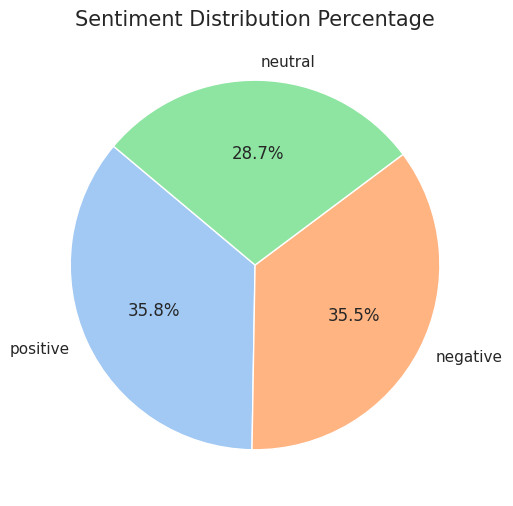

In [418]:
sentiment_counts = df['sentiment'].value_counts()

sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(sentiment_counts)]

plt.figure(figsize=(8, 6))
plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%', # Shows the percentage on the slice
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white'} # Adds a clean border
)

plt.title('Sentiment Distribution Percentage', fontsize=15)
plt.show()

In [419]:
results = run_full_benchmark(
        df,
        target_col="sentiment",
        run_embeddings=True,
        embedding_pipeline="light",
        vectorizers=vectorizers,
        classifiers=classifiers,
    )


═════════════════════════════════════════════════════════════════
  BENCHMARK SPARSE (BoW - TF-IDF)
═════════════════════════════════════════════════════════════════
  → Application du pipeline texte : light
  [light] BoW + Logistic Regression → F1=0.7941  Acc=0.7923
  [light] BoW + SVM → F1=0.7751  Acc=0.7743
  [light] BoW + Random Forest → F1=0.7580  Acc=0.7562
  [light] TFIDF-word + Logistic Regression → F1=0.8045  Acc=0.8059
  [light] TFIDF-word + SVM → F1=0.8329  Acc=0.8330
  [light] TFIDF-word + Random Forest → F1=0.7526  Acc=0.7517
  [light] TF-IDF-char + Logistic Regression → F1=0.8093  Acc=0.8081
  [light] TF-IDF-char + SVM → F1=0.8256  Acc=0.8239
  [light] TF-IDF-char + Random Forest → F1=0.7663  Acc=0.7652
  → Application du pipeline texte : stopwords
  [stopwords] BoW + Logistic Regression → F1=0.7669  Acc=0.7652
  [stopwords] BoW + SVM → F1=0.7666  Acc=0.7652
  [stopwords] BoW + Random Forest → F1=0.7347  Acc=0.7336
  [stopwords] TFIDF-word + Logistic Regression → F1=0.80

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/70 [00:00<?, ?it/s]

  [embed/light] CamemBERT + Logistic Regression → F1=0.8165  Acc=0.8149
  [embed/light] CamemBERT + SVM → F1=0.8302  Acc=0.8284
  [embed/light] CamemBERT + Random Forest → F1=0.7778  Acc=0.7788

═════════════════════════════════════════════════════════════════
 (top 10 per F1 Test)
═════════════════════════════════════════════════════════════════
     pipeline  vectorizer          classifier  acc_train  acc_test  f1_train  f1_test
     stemming  TFIDF-word                 SVM     0.9983    0.8397    0.9983   0.8399
        light  TFIDF-word                 SVM     0.9983    0.8330    0.9983   0.8329
        light   CamemBERT                 SVM     0.9740    0.8284    0.9741   0.8302
   stop_lemma  TFIDF-word                 SVM     0.9972    0.8284    0.9972   0.8280
        light TF-IDF-char                 SVM     0.9921    0.8239    0.9921   0.8256
     stemming TF-IDF-char                 SVM     0.9915    0.8239    0.9915   0.8253
     stemming  TFIDF-word Logistic Regression    

In [420]:
# ── Données ───────────────────────────────────────────────────────────────────
col = "text_stemming"
if col not in df.columns:
    df[col] = df["text"].apply(pipeline_stemming)

X_train, X_test, y_train, y_test = train_test_split(
    df[col], df["sentiment"],
    test_size=0.2, random_state=42, stratify=df["sentiment"]
)

# ── Grille ────────────────────────────────────────────────────────────────────
param_grid = {
    "tfidf__ngram_range"  : [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features" : [20_000, 30_000, 40_000, 50_000, 60_000],
    "tfidf__min_df"       : [1, 2, 3],
    "svm__C"              : [0.001, 0.01, 0.1, 1, 10, 20, 100],
}

grid_list = list(ParameterGrid(param_grid))
print(f"Nombre de combinaisons : {len(grid_list)}")

# ── Recherche sur train/test split simple ─────────────────────────────────────
records = []

for i, params in enumerate(grid_list):
    pipe = SklearnPipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            sublinear_tf=True,
            ngram_range=params["tfidf__ngram_range"],
            max_features=params["tfidf__max_features"],
            min_df=params["tfidf__min_df"],
        )),
        ("svm", LinearSVC(
            C=params["svm__C"],
            max_iter=5000,
            random_state=42,
        )),
    ])

    pipe.fit(X_train, y_train)

    rec = {
        **params,
        "f1_train" : f1_score(y_train, pipe.predict(X_train), average="weighted"),
        "f1_test"  : f1_score(y_test,  pipe.predict(X_test),  average="weighted"),
        "acc_test" : accuracy_score(y_test, pipe.predict(X_test)),
    }
    records.append(rec)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{len(grid_list)}] en cours…")

# ── Résultats ─────────────────────────────────────────────────────────────────
results_gs = pd.DataFrame(records).sort_values("f1_test", ascending=False).reset_index(drop=True)

print("\n── Top 10 combinaisons ──────────────────────────────────────")
print(results_gs.head(10).to_string(index=False))

# ── Meilleur modèle ───────────────────────────────────────────────────────────
best_params = results_gs.iloc[0]
print("\n── Meilleurs hyperparamètres ────────────────────────────────")
for k in param_grid:
    print(f"  {k:<30} : {best_params[k]}")
print(f"  {'F1 train':<30} : {best_params['f1_train']:.4f}")
print(f"  {'F1 test':<30} : {best_params['f1_test']:.4f}")
print(f"  {'Acc test':<30} : {best_params['acc_test']:.4f}")

# ── Réentraîner le meilleur pour classification_report ───────────────────────
best_pipe = SklearnPipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word", sublinear_tf=True,
        ngram_range=best_params["tfidf__ngram_range"],
        max_features=best_params["tfidf__max_features"],
        min_df=best_params["tfidf__min_df"],
    )),
    ("svm", LinearSVC(C=best_params["svm__C"], max_iter=5000, random_state=42)),
])
best_pipe.fit(X_train, y_train)

print("\n── Rapport complet (test) ───────────────────────────────────")
print(classification_report(y_test, best_pipe.predict(X_test)))

Nombre de combinaisons : 315
  [10/315] en cours…
  [20/315] en cours…
  [30/315] en cours…
  [40/315] en cours…
  [50/315] en cours…
  [60/315] en cours…
  [70/315] en cours…
  [80/315] en cours…
  [90/315] en cours…
  [100/315] en cours…
  [110/315] en cours…
  [120/315] en cours…
  [130/315] en cours…
  [140/315] en cours…
  [150/315] en cours…
  [160/315] en cours…
  [170/315] en cours…
  [180/315] en cours…
  [190/315] en cours…
  [200/315] en cours…
  [210/315] en cours…
  [220/315] en cours…
  [230/315] en cours…
  [240/315] en cours…
  [250/315] en cours…
  [260/315] en cours…
  [270/315] en cours…
  [280/315] en cours…
  [290/315] en cours…
  [300/315] en cours…
  [310/315] en cours…

── Top 10 combinaisons ──────────────────────────────────────
 svm__C  tfidf__max_features  tfidf__min_df tfidf__ngram_range  f1_train  f1_test  acc_test
    1.0                20000              1             (1, 2)  0.997743 0.842123  0.841986
    1.0                60000              1        